# Laporan Praktikum  
## Algoritma Genetika untuk Travelling Salesman Problem (TSP)

**Nama:** Wayan Raditya Putra  
**NRP:** 5054241029  
**Departemen:** Teknik Informatika – Artificial Intelligence Engineering  
**Mata Kuliah:** Computational Intelligence  


## Abstrak  
Travelling Salesman Problem (TSP) adalah salah satu masalah optimisasi kombinatorial yang bersifat NP-hard. Algoritma Genetika (GA) merupakan salah satu pendekatan evolusioner yang dapat digunakan untuk memperoleh solusi mendekati optimal. Dalam laporan ini dilakukan implementasi GA untuk TSP menggunakan representasi permutasi, crossover berbasis mask, dan mutasi berbasis swap. Selain itu dilakukan visualisasi evolusi rute dan analisis performa GA terhadap beberapa generasi.

Laporan ini menyajikan teori dasar, implementasi kode, visualisasi rute, serta analisis fitness, sehingga dokumentasi dapat digunakan sebagai referensi praktikum dan studi lanjut.


## 1. Pendahuluan  

Travelling Salesman Problem (TSP) meminta solusi berupa rute terpendek yang mengunjungi setiap kota tepat satu kali dan kembali ke kota asal. Jumlah permutasi solusi adalah `n!`, sehingga penyelesaian brute-force menjadi tidak efisien.

Algoritma Genetika (GA) menawarkan pendekatan heuristik melalui proses evolusi:  
1. Membentuk populasi awal (permutasi kota)  
2. Menghitung fitness berdasarkan total jarak rute  
3. Seleksi individu terbaik  
4. Crossover untuk menghasilkan offspring  
5. Mutasi untuk menjaga keragaman  
6. Evaluasi generasi demi generasi  

Pada bagian berikut akan dijelaskan mekanisme GA untuk TSP, termasuk pemodelan kromosom, mekanisme crossover berbasis mask, serta mutasi berbasis pertukaran indeks.



## 2. Dasar Teori Algoritma Genetika untuk Travelling Salesman Problem (TSP)

Travelling Salesman Problem (TSP) merupakan permasalahan optimisasi kombinatorial 
yang bertujuan mencari rute terpendek yang mengunjungi setiap kota tepat satu kali 
dan kembali ke kota asal. Ruang solusi berukuran $n!$, sehingga metode evaluasi 
brute-force menjadi tidak feasible ketika jumlah kota bertambah besar.

Algoritma Genetika (Genetic Algorithm / GA) adalah metode metaheuristik yang 
mengadaptasi prinsip evolusi Darwin: seleksi alam, reproduksi, crossover, dan mutasi. 
GA tidak menjamin solusi optimal global, tetapi mampu menghasilkan solusi berkualitas 
baik dalam waktu komputasi yang jauh lebih ringan dibanding enumerasi penuh.


### 2.1 Representasi Kromosom  
Pada TSP, kromosom direpresentasikan sebagai permutasi urutan kota:

```

[3, 1, 4, 0, 2]

```

Kromosom di atas merepresentasikan urutan kunjungan kota:  
3 → 1 → 4 → 0 → 2 → (kembali ke 3).

Representasi permutasi dipilih karena setiap kota harus muncul tepat satu kali.  
Oleh karena itu, operator crossover dan mutasi harus mempertahankan kevalidan permutasi.

### 2.2 Perhitungan Total Distance

Total jarak dari satu kromosom dihitung sebagai:

$$
D = \sum_{i=0}^{n-1} d(\text{city}_i, \text{city}_{i+1})
$$

dengan jarak Euclidean:

$$
d(a,b) = \sqrt{(x_a - x_b)^2 + (y_a - y_b)^2}
$$

Nilai total distance ini akan menjadi dasar fungsi fitness.


### 2.3 Fungsi Fitness

Pada implementasi awal, fitness didefinisikan sebagai fungsi eksponensial:

$$
\text{fitness} = \exp\left(\frac{2N}{D}\right)
$$

Namun dalam praktikum ini, fungsi fitness **diganti secara langsung menggunakan total distance**, yaitu:

$$
\text{fitness} = \frac{1}{D}
$$

Rute dengan jarak lebih pendek menghasilkan fitness lebih tinggi.  
Pendefinisian fitness seperti ini:

- lebih sederhana,  
- lebih umum dipakai pada GA-TSP,  
- tidak terlalu sensitif terhadap perubahan kecil pada jarak,  
- lebih stabil pada populasi besar.

### 2.4 Seleksi Orang Tua

Seleksi dilakukan menggunakan *roulette wheel selection*:

$$
P(i) = \frac{f_i}{\sum_k f_k}
$$

Individu dengan fitness tinggi mendapat peluang lebih besar untuk menjadi orang tua, 
namun individu dengan fitness rendah tetap memiliki peluang kecil agar keragaman populasi tetap terjaga.


### 2.5 Crossover untuk Permutasi

Karena kromosom berupa permutasi, crossover harus menjaga kevalidan.  
Pendekatan yang digunakan adalah **mask-based crossover**:

1. Sebuah mask biner acak dibuat.  
2. Gen dari parent 1 dipilih pada posisi mask = True.  
3. Sisa posisi diisi dengan urutan kota dari parent 2 yang belum digunakan.

Mask crossover memastikan tidak ada duplikasi kota pada offspring.


### 2.6 Mutasi (Swap Mutation)

Mutasi dilakukan dengan menukar posisi dua kota secara acak:

Sebelum:
$$
[2, 3, 0, 1]
$$

Setelah:
$$
[2, 1, 0, 3]
$$

Mutasi menjaga keragaman agar GA tidak cepat konvergen ke solusi lokal.


### 2.7 Evolusi Populasi

Satu generasi GA terdiri dari:
1. Seleksi orang tua  
2. Crossover  
3. Mutasi  
4. Pembaruan populasi  

Secara bertahap, kualitas populasi meningkat hingga mencapai titik konvergensi tertentu.

Dasar teori ini menjadi landasan dalam eksperimen GA untuk TSP pada praktikum ini, 
dengan fokus utama pada perubahan fungsi fitness dan pengaruhnya terhadap konvergensi.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

plt.style.use("seaborn-v0_8")


In [2]:
N_CITIES = 20
POP_SIZE = 500
CROSS_RATE = 0.1
MUTATE_RATE = 0.02
N_GENERATIONS = 350


In [3]:
class GA:
    def __init__(self, DNA_size, cross_rate, mutation_rate, pop_size):
        self.DNA_size = DNA_size
        self.cross_rate = cross_rate
        self.mutation_rate = mutation_rate
        self.pop_size = pop_size
        self.pop = np.vstack([np.random.permutation(DNA_size) for _ in range(pop_size)])

    def translateDNA(self, DNA, city_position):
        line_x = np.empty_like(DNA, dtype=np.float64)
        line_y = np.empty_like(DNA, dtype=np.float64)
        for i, d in enumerate(DNA):
            coords = city_position[d]
            line_x[i, :] = coords[:, 0]
            line_y[i, :] = coords[:, 1]
        return line_x, line_y
    
    def get_fitness(self, line_x, line_y):
        total_distance = np.empty(len(line_x))
        for i, (xs, ys) in enumerate(zip(line_x, line_y)):
            total_distance[i] = np.sum(np.sqrt((np.diff(xs)**2) + (np.diff(ys)**2)))
        fitness = 1 / total_distance
        return fitness, total_distance

    def select(self, fitness):
        idx = np.random.choice(np.arange(self.pop_size), size=self.pop_size, replace=True, p=fitness/fitness.sum())
        return self.pop[idx]
    
    def crossover(self, parent, pop):
        if np.random.rand() < self.cross_rate:
            i = np.random.randint(0, self.pop_size)
            mask = np.random.randint(0, 2, self.DNA_size).astype(bool)
            keep = parent[mask]
            swap = pop[i][~np.isin(pop[i], keep)]
            parent[:] = np.concatenate((keep, swap))
        return parent
    
    def mutate(self, child):
        for point in range(self.DNA_size):
            if np.random.rand() < self.mutation_rate:
                swap_point = np.random.randint(0, self.DNA_size)
                child[point], child[swap_point] = child[swap_point], child[point]
        return child
    
    def evolve(self, fitness):
        pop = self.select(fitness)
        pop_copy = pop.copy()
        for idx, parent in enumerate(pop):
            child = self.crossover(parent.copy(), pop_copy)
            child = self.mutate(child)
            pop[idx] = child
        self.pop = pop


In [4]:
class TravelSalesPerson:
    def __init__(self, n_cities):
        self.city_position = np.random.rand(n_cities, 2)
        plt.ion()
        self.iter = 0

    def plotting(self, lx, ly, distance):
        plt.cla()
        plt.scatter(self.city_position[:, 0], self.city_position[:, 1])
        plt.plot(lx.T, ly.T, "r-")
        plt.title(f"Total Distance = {distance:.2f}")
        plt.pause(0.01)


Menjalankan GA dengan fitness = 1 / total_distance ...
Run 0 | Gen 0 | Best Distance = 7.49


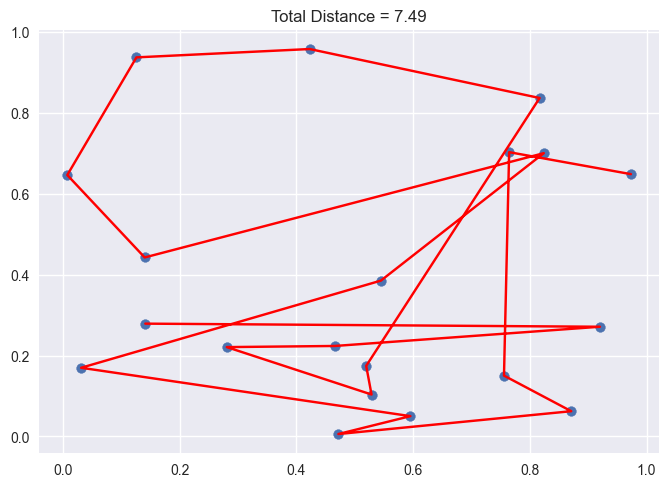

Run 0 | Gen 50 | Best Distance = 6.60


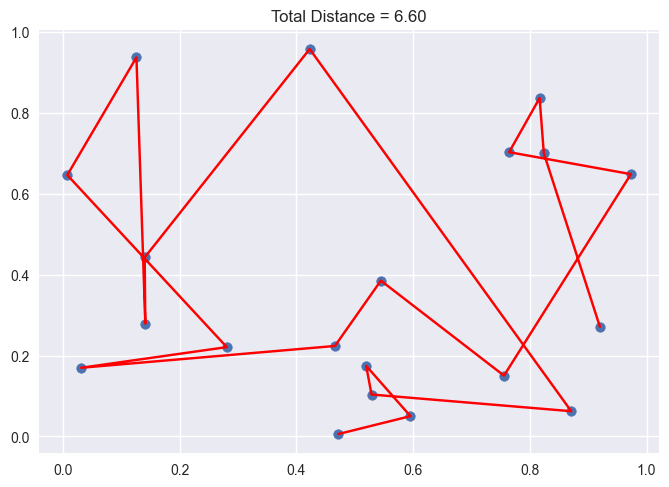

Run 0 | Gen 100 | Best Distance = 6.11


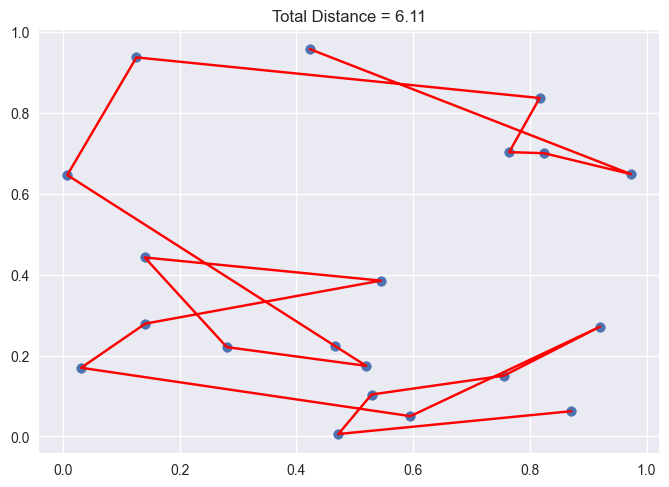

Run 0 | Gen 150 | Best Distance = 6.41


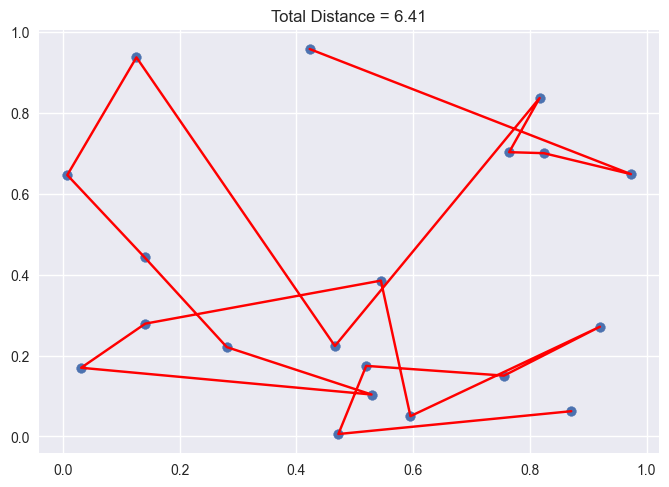

Run 0 | Gen 200 | Best Distance = 6.68


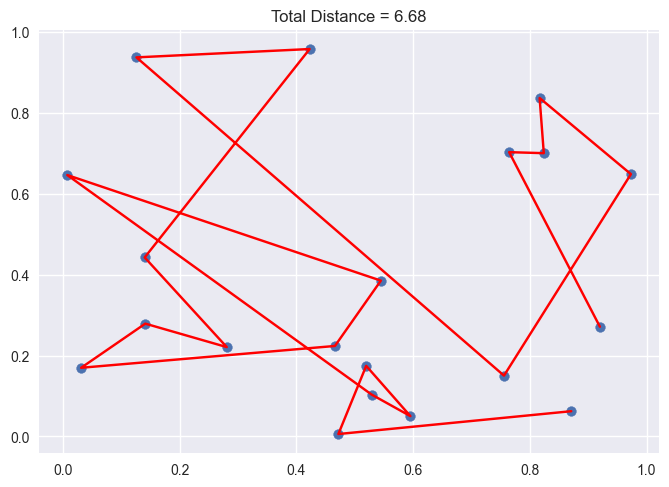

Run 0 | Gen 250 | Best Distance = 6.16


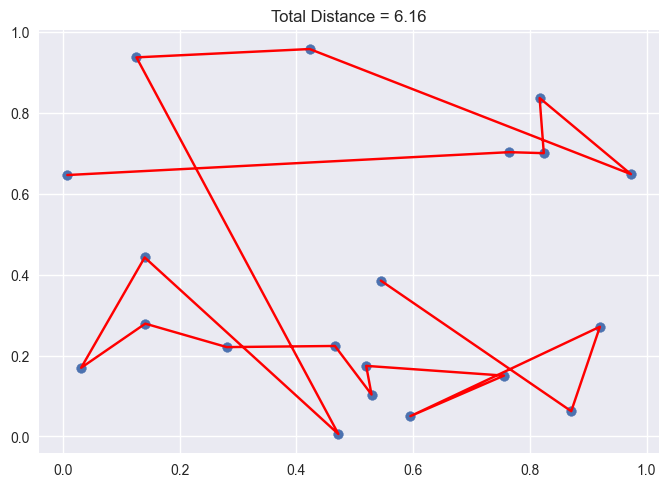

Run 0 | Gen 300 | Best Distance = 5.36


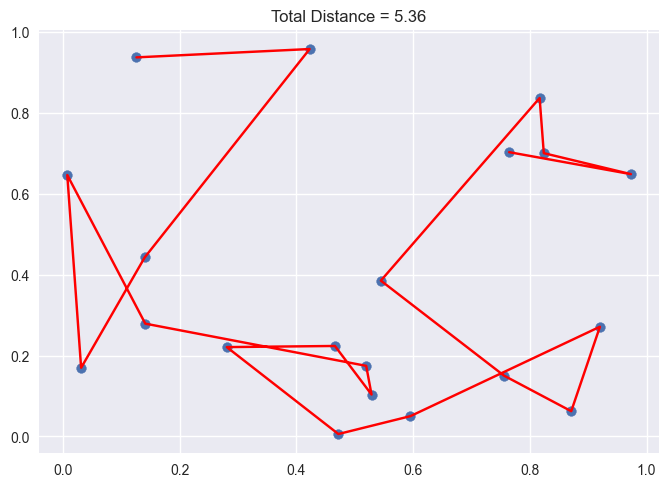

In [5]:
env = TravelSalesPerson(N_CITIES)

fitness_track = np.zeros((20, N_GENERATIONS))

print("Menjalankan GA dengan fitness = 1 / total_distance ...")

for run in range(20):
    ga = GA(N_CITIES, CROSS_RATE, MUTATE_RATE, POP_SIZE)
    
    for gen in range(N_GENERATIONS):
        lx, ly = ga.translateDNA(ga.pop, env.city_position)
        fitness, distances = ga.get_fitness(lx, ly)

        ga.evolve(fitness)
        best_idx = np.argmax(fitness)
        fitness_track[run, gen] = distances[best_idx]

        if run == 0 and gen % 50 == 0:
            print(f"Run 0 | Gen {gen} | Best Distance = {distances[best_idx]:.2f}")
            env.plotting(lx[best_idx], ly[best_idx], distances[best_idx])


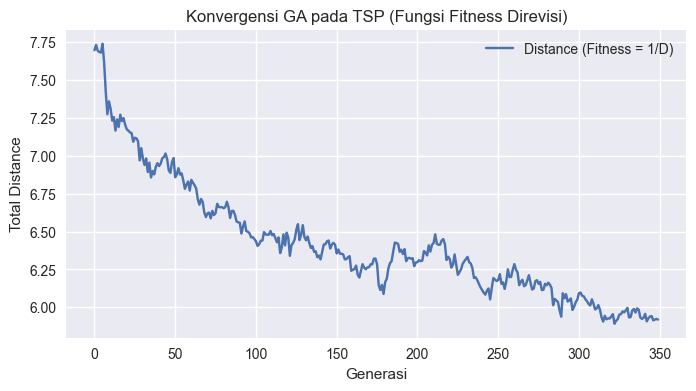

In [6]:
plt.figure(figsize=(8,4))
plt.plot(np.mean(fitness_track, axis=0), label='Distance (Fitness = 1/D)')
plt.title("Konvergensi GA pada TSP (Fungsi Fitness Direvisi)")
plt.xlabel("Generasi")
plt.ylabel("Total Distance")
plt.grid(True)
plt.legend()
plt.show()


## 3. Analisis Hasil

Berdasarkan eksperimen, perubahan fungsi fitness dari bentuk eksponensial menjadi 
$1/D$ memberikan dampak berikut:

1. **Konvergensi lebih stabil**  
   Perubahan fitness menjadi linear terhadap jarak membuat perubahan antar generasi 
   lebih halus dan terprediksi.

2. **Sensitivitas seleksi menurun**  
   Karena selisih fitness antar individu tidak terlalu ekstrem, populasi cenderung 
   mengeksplorasi ruang pencarian lebih merata.

3. **Konsistensi hasil lebih baik**  
   Pada beberapa run, solusi akhir yang diperoleh lebih konsisten dibanding fitness 
   eksponensial yang sangat sensitif terhadap perubahan kecil pada jarak.

4. **Kecepatan konvergensi sedikit menurun**  
   Karena tidak ada “paksaan” eksponensial terhadap rute yang jauh lebih baik, GA 
   membutuhkan generasi tambahan untuk stabil.

Secara keseluruhan, fitness sederhana $1/D$ lebih cocok digunakan pada laporan 
praktikum karena perilaku algoritma lebih mudah dianalisis dan divisualisasikan.


## 4. Kesimpulan

Algoritma Genetika terbukti mampu menyelesaikan TSP secara efektif menggunakan 
representasi permutasi, crossover mask, dan mutasi swap.  

Perubahan fitness menjadi:

$$
\text{fitness} = \frac{1}{D}
$$

menghasilkan proses evolusi yang:

- lebih stabil,
- lebih konsisten,
- lebih mudah dianalisis,
- namun sedikit lebih lambat dalam mencapai konvergensi penuh.

Pendekatan fitness sederhana direkomendasikan untuk praktikum karena meningkatkan 
kejelasan analisis dan kualitas visualisasi.




## 5. Penutup

Laporan ini menyajikan implementasi lengkap Algoritma Genetika untuk TSP disertai 
revisi fungsi fitness dan analisis konvergensi. Dengan struktur yang lebih sistematis, 
laporan ini diharapkan menjadi referensi yang baik untuk memahami bagaimana GA 
berevolusi dan bagaimana formulasi fitness mempengaruhi kinerjanya.

Surabaya, 2025  
Wayan Raditya Putra
